# 01 - Exploration
**Concept: vectors and matrices.** Data is a matrix `X` (rows = houses, columns = features) and a vector `y` (prices).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # make `src` importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_houses, to_arrays, FEATURES, TARGET

In [2]:
df = load_houses()
print(df.shape)
df.head()

(500, 4)


,size_m2,bedrooms,age_years,price
0,132.2,3,28.5,165191.0
1,78.4,2,29.5,115760.0
2,150.0,4,42.5,163645.0
3,157.6,1,0.2,196117.0
4,42.0,2,42.7,78720.0


In [3]:
df.describe()

,size_m2,bedrooms,age_years,price
count,500.000000,500.000000,500.000000,500.000000
mean,119.514200,3.014000,25.220200,153603.034000
std,38.298721,1.404903,14.666403,39922.949416
min,30.000000,1.000000,0.000000,41616.000000
25%,93.350000,2.000000,12.200000,127904.750000
50%,120.150000,3.000000,24.950000,153460.500000
75%,143.450000,4.000000,38.025000,179181.500000
max,236.600000,5.000000,50.000000,274136.000000


## Matrix and vector
`X` has shape `(n_houses, n_features)`. One house is a **vector** (a row of `X`).

In [4]:
X, y = to_arrays(df)
print('X:', X.shape, '| y:', y.shape)
print('First house (vector):', X[0])

X: (500, 3) | y: (500,)
First house (vector): [132.2   3.   28.5]


## Dot product = a prediction
With weights `w`, a price is the dot product `w0 + w1*size + w2*bedrooms + w3*age`.
For all houses at once: `y_hat = X_b @ w` (matrix x vector).

In [5]:
w = np.array([50_000, 900, 4_000, -600])   # bias, size, bedrooms, age
x = np.concatenate([[1], X[0]])            # prepend 1 for the bias

manual = sum(wi * xi for wi, xi in zip(w, x))
print('manual :', manual)
print('np.dot :', np.dot(w, x))
print('actual :', y[0])

manual : 163880.0
np.dot : 163880.0
actual : 165191.0


In [6]:
Xb = np.column_stack([np.ones(len(X)), X])  # design matrix (n, 4)
y_hat = Xb @ w                              # all predictions in ONE operation
print(Xb.shape, '@', w.shape, '->', y_hat.shape)

(500, 4) @ (4,) -> (500,)


## Visual exploration

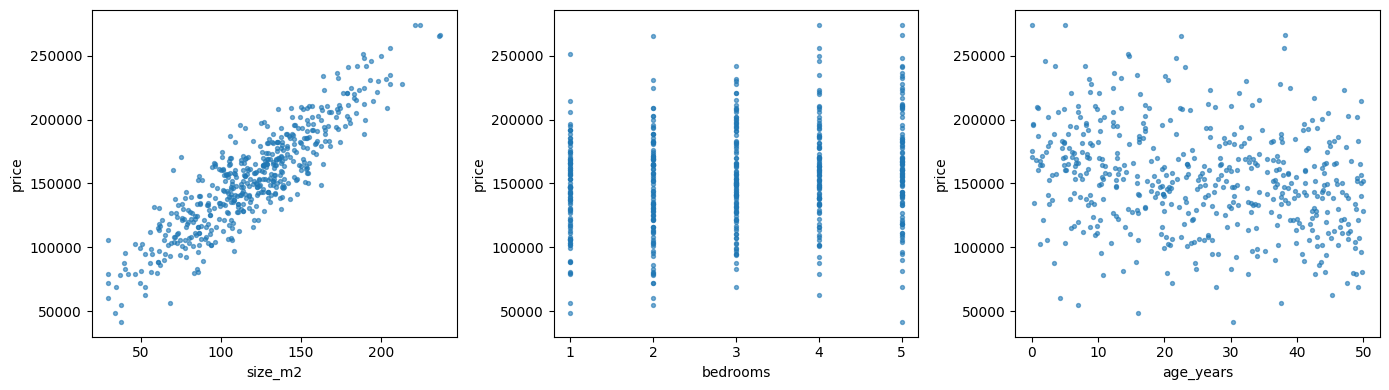

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, FEATURES):
    ax.scatter(df[col], df[TARGET], s=8, alpha=0.6)
    ax.set_xlabel(col); ax.set_ylabel(TARGET)
plt.tight_layout(); plt.show()

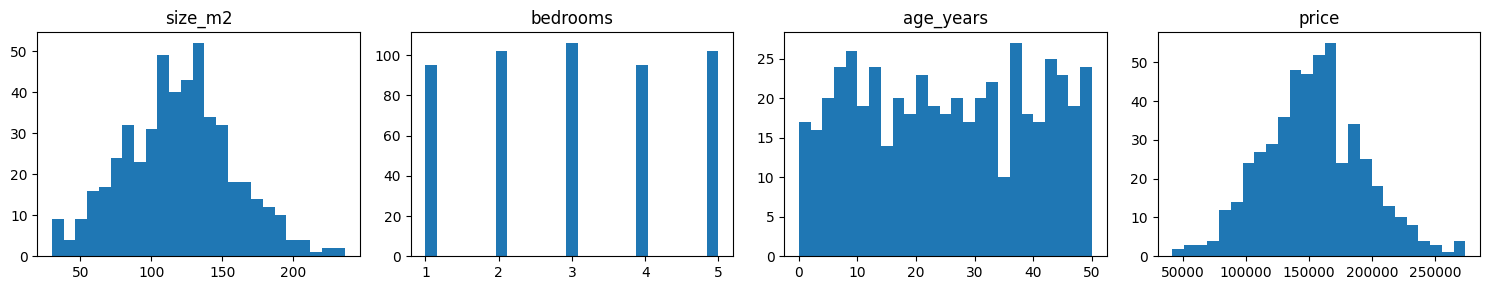

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, col in zip(axes, FEATURES + [TARGET]):
    ax.hist(df[col], bins=25); ax.set_title(col)
plt.tight_layout(); plt.show()

**Takeaway:** size shows a strong positive trend with price; age a weaker negative one; bedrooms is nearly flat on its own.